# 🔐 AI-Powered Intrusion Detection System
### CLO4 — Information Security Assignment
**Dataset:** CIC-IDS2017 — Friday DDoS Afternoon Traffic

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load Dataset

In [2]:
# ⚠️ Update this path to wherever you placed the CSV
DATA_PATH = '../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

df = pd.read_csv(DATA_PATH)

# Strip whitespace from column names (CIC-IDS2017 known issue)
df.columns = df.columns.str.strip()

print(f'📦 Dataset shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
df.head()

📦 Dataset shape: (225745, 79)
📋 Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Class distribution
print('🏷️  Label Distribution:')
print(df['Label'].value_counts())
print(f'\nClass balance ratio: {df["Label"].value_counts(normalize=True).round(3).to_dict()}')

🏷️  Label Distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Class balance ratio: {'DDoS': 0.567, 'BENIGN': 0.433}


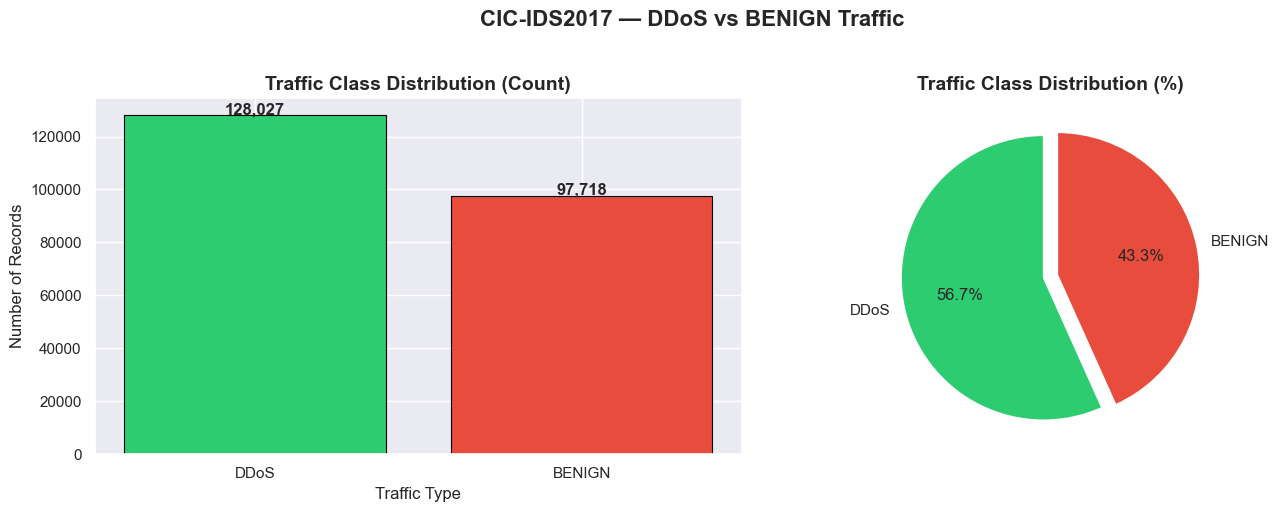

In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Traffic Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Number of Records')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*len(counts))
axes[1].set_title('Traffic Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('CIC-IDS2017 — DDoS vs BENIGN Traffic', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../frontend/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Basic statistics
print('📊 Dataset Info:')
df.info()
print('\n📈 Numerical Statistics:')
df.describe().T

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        225745 non-null  int64  
 12  Bwd Packet Length Mean       225745 non-nu

,count,mean,std,min,25%,50%,75%,max
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,80.0,80.0,80.0,65532.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,71180.0,1452333.0,8805237.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,2.0,3.0,5.0,1932.0
Total Backward Packets,225745.0,4.572775e+00,2.175536e+01,0.0,1.0,4.0,5.0,2942.0
Total Length of Fwd Packets,225745.0,9.394633e+02,3.249403e+03,0.0,26.0,30.0,63.0,183012.0
...,...,...,...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,0.0,0.0,1862.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,0.0,0.0,8239725.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,0.0,0.0,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,0.0,0.0,8253838.0,120000000.0


In [6]:
# Check for missing and infinite values
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Infinite values: {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}')

Missing values: 4
Infinite values: 64


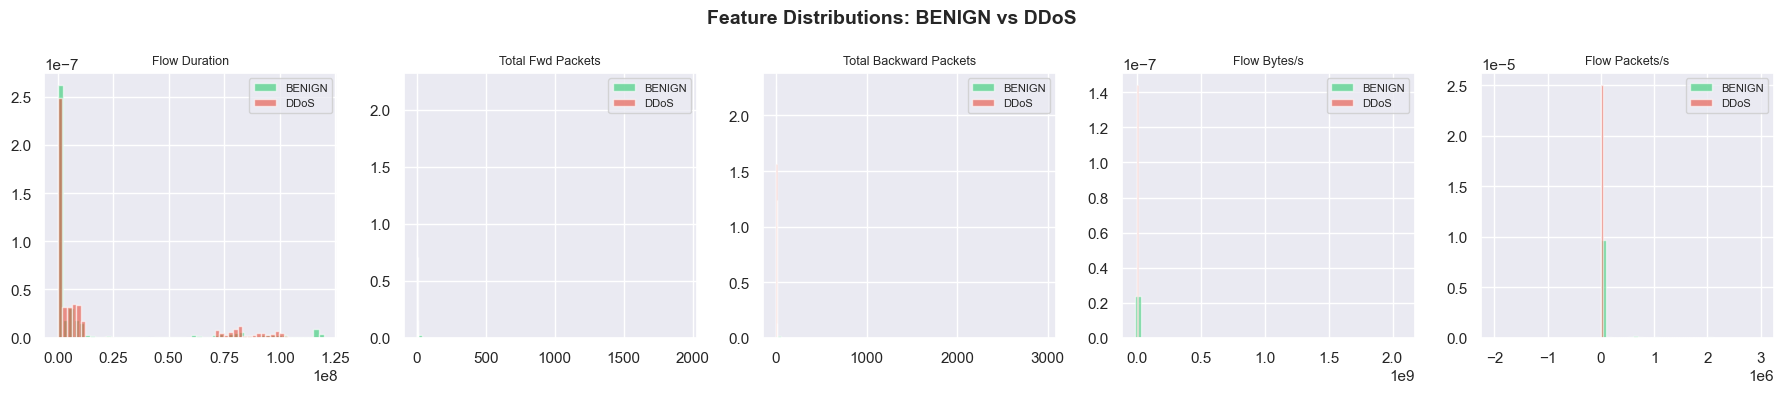

In [7]:
# Feature distribution comparison: BENIGN vs DDoS
key_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'Flow Bytes/s', 'Flow Packets/s']

# Only use features that exist in the dataset
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))
for ax, feat in zip(axes, key_features):
    for label, color in [('BENIGN', '#2ecc71'), ('DDoS', '#e74c3c')]:
        subset = df[df['Label'] == label][feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions: BENIGN vs DDoS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../frontend/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [8]:
# Step 1: Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 2: Drop rows with NaN
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f'Rows removed (inf/NaN): {before - after}')
print(f'Remaining rows: {after:,}')

# Step 3: Encode labels
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])
print(f'\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Step 4: Separate features and target
X = df.drop(columns=['Label', 'Label_encoded'])

# Drop non-numeric columns if any
X = X.select_dtypes(include=[np.number])
y = df['Label_encoded']

print(f'\nFeatures shape: {X.shape}')
print(f'Target shape: {y.shape}')

Rows removed (inf/NaN): 34
Remaining rows: 225,711

Label encoding: {'BENIGN': 0, 'DDoS': 1}

Features shape: (225711, 78)
Target shape: (225711,)


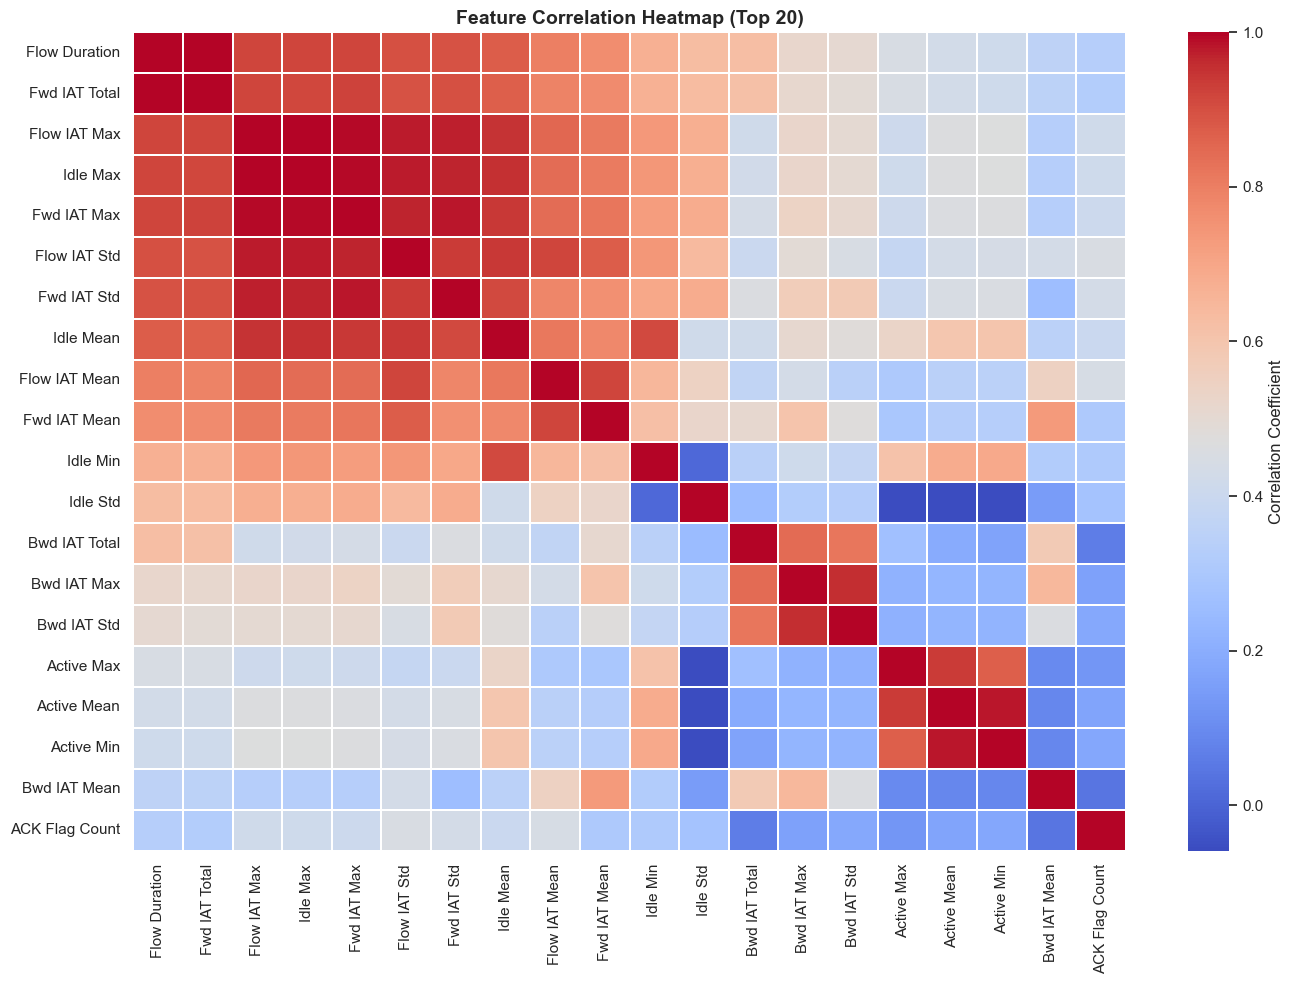

In [9]:
# Step 5: Correlation heatmap (top 20 features)
corr_matrix = X.corr().abs()
top_features = corr_matrix['Flow Duration'].nlargest(20).index if 'Flow Duration' in X.columns else X.columns[:20]

plt.figure(figsize=(14, 10))
sns.heatmap(X[top_features].corr(), annot=False, cmap='coolwarm', linewidths=0.3,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../frontend/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Step 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 7: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set:     {X_test_scaled.shape}')
print(f'Class balance in train: {pd.Series(y_train).value_counts().to_dict()}')

Training set: (180568, 78)
Test set:     (45143, 78)
Class balance in train: {1: 102420, 0: 78148}


## 5. Model Training

In [11]:
# Model 1: Random Forest (Primary)
print('🌲 Training Random Forest Classifier...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print('✅ Random Forest trained!')

# Model 2: Decision Tree (Baseline)
print('\n🌳 Training Decision Tree Classifier...')
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
print('✅ Decision Tree trained!')

🌲 Training Random Forest Classifier...
✅ Random Forest trained!

🌳 Training Decision Tree Classifier...
✅ Decision Tree trained!


## 6. Evaluation

In [12]:
def evaluate_model(model, X_test, y_test, model_name, label_encoder):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f'\n{'='*50}')
    print(f'  {model_name} — Evaluation Results')
    print(f'{'='*50}')
    print(f'  Accuracy:  {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    return y_pred, {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


rf_preds, rf_metrics = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest', le)
dt_preds, dt_metrics = evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree', le)


  Random Forest — Evaluation Results
  Accuracy:  0.9999 (99.99%)
  Precision: 0.9999
  Recall:    0.9999
  F1-Score:  0.9999

  Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143


  Decision Tree — Evaluation Results
  Accuracy:  0.9996 (99.96%)
  Precision: 0.9996
  Recall:    0.9996
  F1-Score:  0.9996

  Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



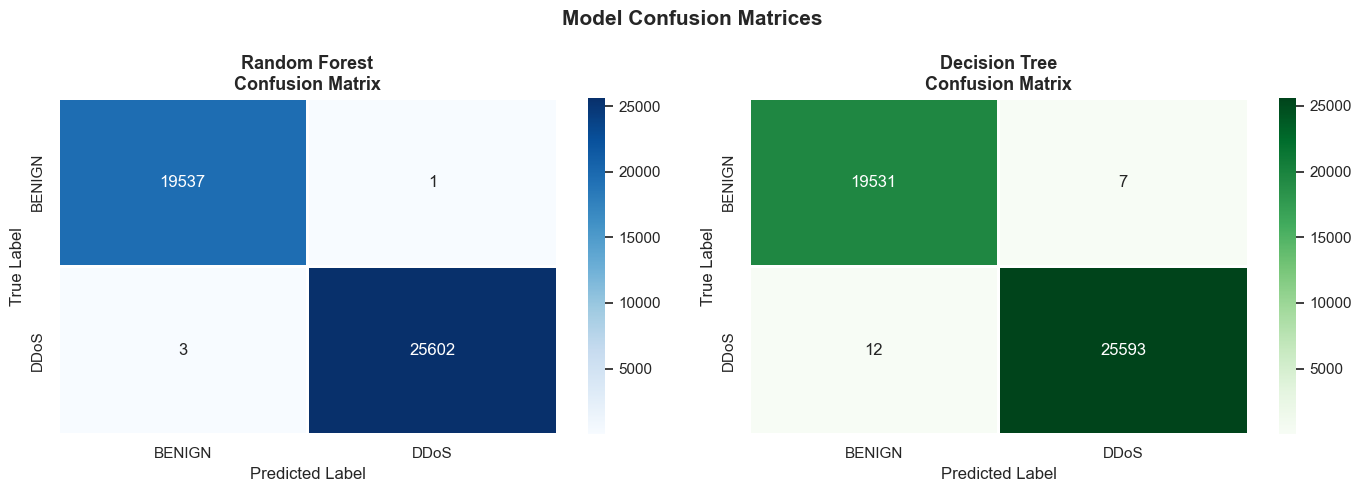

In [13]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in [
    (axes[0], rf_preds, 'Random Forest', 'Blues'),
    (axes[1], dt_preds, 'Decision Tree', 'Greens')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Model Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../frontend/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

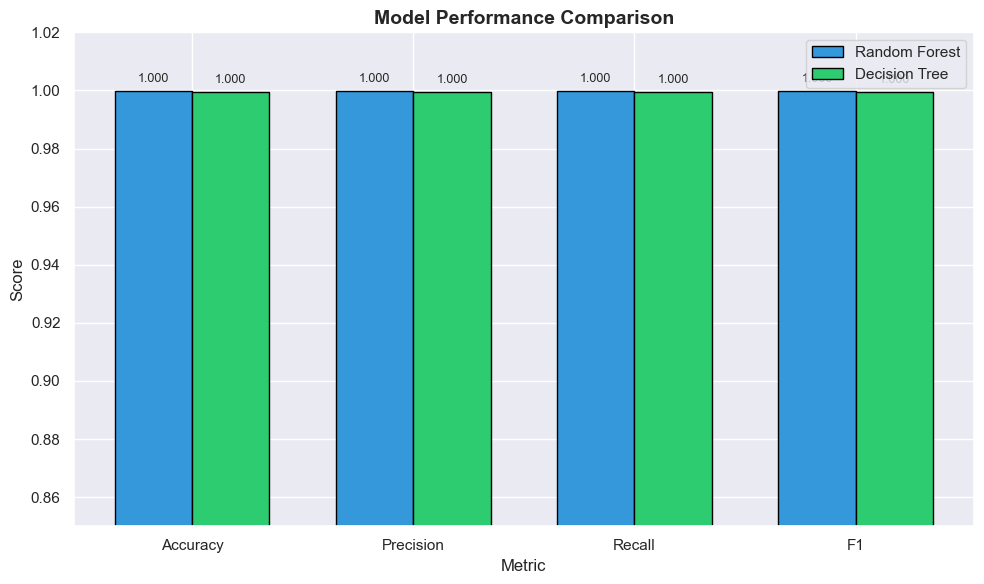

In [14]:
# Model Comparison Bar Chart
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
rf_vals = [rf_metrics[m] for m in metrics_names]
dt_vals = [dt_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, dt_vals, width, label='Decision Tree', color='#2ecc71', edgecolor='black')

ax.set_ylim(0.85, 1.02)
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_names])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../frontend/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

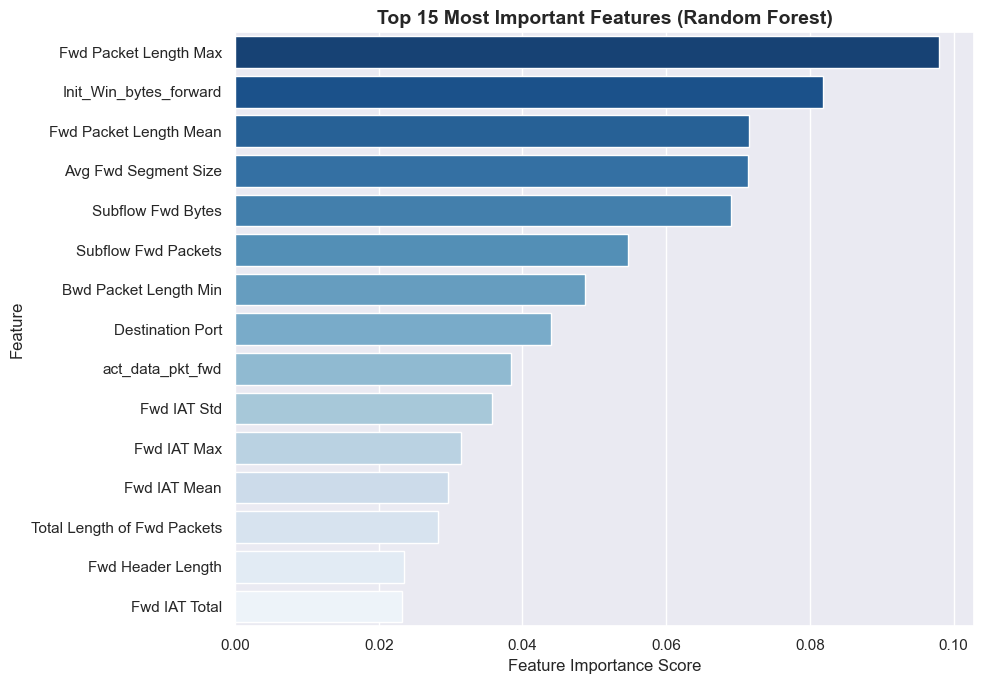

Top 5 features:
                   Feature  Importance
6    Fwd Packet Length Max    0.097951
66  Init_Win_bytes_forward    0.081768
8   Fwd Packet Length Mean    0.071524
53    Avg Fwd Segment Size    0.071391
63       Subflow Fwd Bytes    0.069088


In [15]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../frontend/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(feat_imp_df.head())

## 7. Save Model & Artifacts

In [16]:
import os, joblib

os.makedirs('../backend', exist_ok=True)

# Save both models separately
joblib.dump(rf_model,          '../backend/model.pkl')        # Random Forest
joblib.dump(dt_model,          '../backend/dt_model.pkl')     # Decision Tree  ← NEW
joblib.dump(scaler,            '../backend/scaler.pkl')
joblib.dump(le,                '../backend/label_encoder.pkl')
joblib.dump(list(X.columns),   '../backend/feature_names.pkl')

# Save metrics for both models so the API can serve them  ← NEW
metrics_to_save = {
    'random_forest': {
        'accuracy':  round(rf_metrics['accuracy'],  4),
        'precision': round(rf_metrics['precision'], 4),
        'recall':    round(rf_metrics['recall'],    4),
        'f1':        round(rf_metrics['f1'],        4),
    },
    'decision_tree': {
        'accuracy':  round(dt_metrics['accuracy'],  4),
        'precision': round(dt_metrics['precision'], 4),
        'recall':    round(dt_metrics['recall'],    4),
        'f1':        round(dt_metrics['f1'],        4),
    }
}
joblib.dump(metrics_to_save, '../backend/metrics.pkl')        # ← NEW

print('✅ Saved:')
print('  backend/model.pkl         (Random Forest)')
print('  backend/dt_model.pkl      (Decision Tree)')
print('  backend/scaler.pkl')
print('  backend/label_encoder.pkl')
print('  backend/feature_names.pkl')
print('  backend/metrics.pkl       (accuracy/F1 for both models)')
print()
print('📊 Random Forest:', {k: f"{v*100:.2f}%" for k, v in metrics_to_save['random_forest'].items()})
print('📊 Decision Tree:', {k: f"{v*100:.2f}%" for k, v in metrics_to_save['decision_tree'].items()})

✅ Saved:
  backend/model.pkl         (Random Forest)
  backend/dt_model.pkl      (Decision Tree)
  backend/scaler.pkl
  backend/label_encoder.pkl
  backend/feature_names.pkl
  backend/metrics.pkl       (accuracy/F1 for both models)

📊 Random Forest: {'accuracy': '99.99%', 'precision': '99.99%', 'recall': '99.99%', 'f1': '99.99%'}
📊 Decision Tree: {'accuracy': '99.96%', 'precision': '99.96%', 'recall': '99.96%', 'f1': '99.96%'}


## 8. Security Analysis

### Critical Findings

**Why Random Forest was chosen:**
- Handles high-dimensional network traffic features well
- Resistant to overfitting through ensemble averaging
- Provides feature importance scores useful for security analysts
- Does not require feature scaling (though we applied it for consistency)

**Security implications of Recall:**
- **High Recall for DDoS** = fewer attacks missed → fewer false negatives → fewer undetected attacks reaching the network
- A false negative (missed DDoS) is far more dangerous than a false positive (blocking legitimate traffic)
- This model prioritizes **detection over false alarms**, which aligns with a security-first posture

**Limitations:**
- Model is trained on simulated lab traffic — real-world zero-day DDoS variants may not be detected
- Dataset is static; attackers adapt. Model must be retrained periodically.
- Feature extraction from raw packets requires tools like CICFlowMeter in production

**Future Improvements:**
- LSTM/Transformer models for temporal traffic patterns
- Online learning for real-time model updates
- Integration with SIEM/SOAR platforms